# Agrupando colores

Vamos a crear imagenes con una cantidad fija de colores

#### 1. Importa las librerias
Vamos a necesitar `KMeans` de `sklearn.cluster`, `imread` de `matplotlib.image`, `matplotlib.pyplot` y `numpy`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.cluster import KMeans

#### 2. Lee una imagen
Utiliza alguna foto que tengas en tu ordenador y leela con la función `imread`

Consejo: utiliza una imagen pequeña si no quieres tardar una eternidad en que se ejecute el kmeans

In [2]:
image = plt.imread("data/imagen.png")
image

array([[[0.16078432, 0.16862746, 0.11372549, 1.        ],
        [0.21176471, 0.21960784, 0.16862746, 1.        ],
        [0.1764706 , 0.18431373, 0.13725491, 1.        ],
        ...,
        [0.0627451 , 0.07450981, 0.01960784, 1.        ],
        [0.0627451 , 0.07450981, 0.01960784, 1.        ],
        [0.0627451 , 0.07450981, 0.01960784, 1.        ]],

       [[0.19215687, 0.2       , 0.14509805, 1.        ],
        [0.16078432, 0.16862746, 0.11764706, 1.        ],
        [0.10588235, 0.11372549, 0.07058824, 1.        ],
        ...,
        [0.0627451 , 0.07058824, 0.01960784, 1.        ],
        [0.0627451 , 0.07058824, 0.01960784, 1.        ],
        [0.0627451 , 0.07058824, 0.01960784, 1.        ]],

       [[0.21568628, 0.22352941, 0.16470589, 1.        ],
        [0.11764706, 0.1254902 , 0.07058824, 1.        ],
        [0.04705882, 0.05490196, 0.01568628, 1.        ],
        ...,
        [0.0627451 , 0.07058824, 0.01960784, 1.        ],
        [0.0627451 , 0.070588

In [3]:
image.shape

(500, 367, 4)

Muestra la imagen para ver que se ha cargado bien

In [4]:
image = image[:, :, :3].copy()
image.shape

(500, 367, 3)

In [5]:
image

array([[[0.16078432, 0.16862746, 0.11372549],
        [0.21176471, 0.21960784, 0.16862746],
        [0.1764706 , 0.18431373, 0.13725491],
        ...,
        [0.0627451 , 0.07450981, 0.01960784],
        [0.0627451 , 0.07450981, 0.01960784],
        [0.0627451 , 0.07450981, 0.01960784]],

       [[0.19215687, 0.2       , 0.14509805],
        [0.16078432, 0.16862746, 0.11764706],
        [0.10588235, 0.11372549, 0.07058824],
        ...,
        [0.0627451 , 0.07058824, 0.01960784],
        [0.0627451 , 0.07058824, 0.01960784],
        [0.0627451 , 0.07058824, 0.01960784]],

       [[0.21568628, 0.22352941, 0.16470589],
        [0.11764706, 0.1254902 , 0.07058824],
        [0.04705882, 0.05490196, 0.01568628],
        ...,
        [0.0627451 , 0.07058824, 0.01960784],
        [0.0627451 , 0.07058824, 0.01960784],
        [0.0627451 , 0.07058824, 0.01960784]],

       ...,

       [[0.07843138, 0.07843138, 0.03921569],
        [0.04705882, 0.04705882, 0.00784314],
        [0.03137255, 0

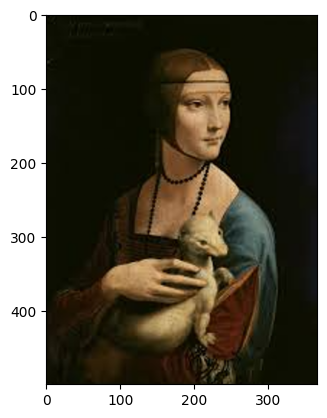

In [6]:
plt.imshow(image)

#### 3. Modifica la estructura de la imagen
Queremos que cada pixel sea una observación por lo que tenemos que transformar nuestra imagen de un vector de forma (alto, ancho, color) a (alto x ancho, color). Color será siempre 3, que son los tres canales de los colores.

Ej: (300, 400, 3) -> (120000, 3)

In [8]:
image.shape

(500, 367, 3)

In [10]:
X = image.reshape(-1, 3)
X.shape

(183500, 3)

In [ ]:
image[1]

array([[0.19215687, 0.2       , 0.14509805],
       [0.16078432, 0.16862746, 0.11764706],
       [0.10588235, 0.11372549, 0.07058824],
       ...,
       [0.0627451 , 0.07058824, 0.01960784],
       [0.0627451 , 0.07058824, 0.01960784],
       [0.0627451 , 0.07058824, 0.01960784]], dtype=float32)

In [19]:
len(image)

500

In [20]:
len(image) * len(image[0])

183500

In [21]:
X.shape

(183500, 3)

#### 4. K-means
Haz un k-means con la imagen de entrada (Con la nueva forma que le hemos dado). K será el número de colores que quieras que tenga tu imagen de salida

In [42]:
km = KMeans(n_clusters=3, n_init=10, random_state=11)
km.fit(X)

KMeans(n_clusters=3, n_init=10, random_state=11)

In [43]:
km.labels_

array([0, 2, 0, ..., 0, 0, 0], dtype=int32)

In [44]:
df_cluster = pd.DataFrame(X, columns = ["R", "G", "B"])
df_cluster["cluster"] = km.labels_
df_cluster

,R,G,B,cluster
0,0.160784,0.168627,0.113725,0
1,0.211765,0.219608,0.168627,2
2,0.176471,0.184314,0.137255,0
3,0.070588,0.078431,0.035294,0
4,0.035294,0.043137,0.000000,0
...,...,...,...,...
183495,0.050980,0.050980,0.011765,0
183496,0.050980,0.050980,0.011765,0
183497,0.050980,0.050980,0.011765,0
183498,0.050980,0.050980,0.011765,0


In [45]:
df_cluster["cluster"].value_counts()

cluster
0    140919
2     23173
1     19408
Name: count, dtype: int64

#### 5. Sustituye cada valor por su centroide

Una vez hemos entrenado el kmeans entre otros parametros de salida tiene `cluster_centers_` y `labels_`. Utilizlos para crear una nueva imagen (recuerda que las imagenes simplemente son vectores numéricos) en la que cada pixel se sustituye por su centroide correspondiente.

In [46]:
km.cluster_centers_

array([[0.07752633, 0.07044972, 0.01993981],
       [0.6999248 , 0.5702061 , 0.39734435],
       [0.37020946, 0.28603002, 0.17708352]], dtype=float32)

#### 6. Modifica la estructura de la imagen
Para trabajar con el k-means requeriamos que la imagen original fuese un solo vector, ahora como queremos volver a tener la imagen para volver mostrarla debemos hacer el proceso inverso a el paso 3. (Si has guardado la forma de la imagen original te será más facil hacer este paso)

In [47]:
segmented_img = km.cluster_centers_[km.labels_]
segmented_img = segmented_img.reshape(image.shape)

#### 7. Imprime y guarda en tu ordenador la imagen resultante

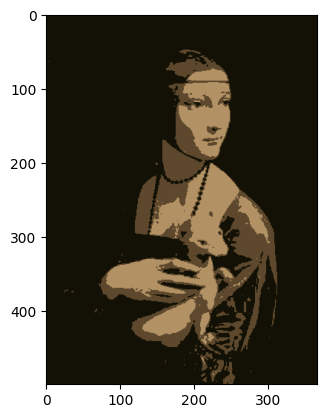

In [48]:
plt.imshow(segmented_img)

#### 8. Crea una función
Crea una función que tenga como argumentos de entrada una imagen, el numero de colores que quieres que tenga, y si se quiere guardar o mostrar por pantalla

In [60]:
def cluster_img(path, n_c, desc = False):
    image = plt.imread(path)
    image = image[:, :, :3]
    X = image.reshape(-1, 3)
    print(X.shape)
    
    km = KMeans(n_clusters=n_c, n_init=10, random_state=11)
    km.fit(X)

    img = km.cluster_centers_[km.labels_]
    img = segmented_img.reshape(image.shape)

    if desc == True:
        plt.imshow(img)
        plt.savefig("data/image_cluster.jpg")
        return "Imagen Guardada"
    else:
        plt.imshow(img)

    return img

(183500, 3)


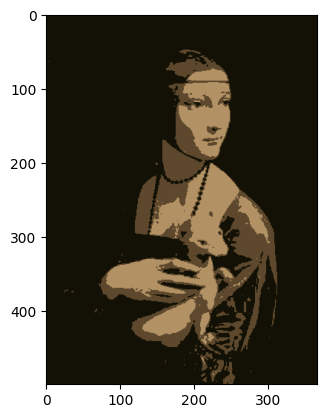

In [61]:
ruta = "data/imagen.png"
colores = 4

resp_img = cluster_img(ruta, colores, True)

